In [ ]:
import torch 
import pandas as pd 
import numpy as np
import os
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torch.utils.data import DataLoader 

from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
from lincs_gsnn.models.ODEFunc import ODEFunc
from lincs_gsnn.models.ODEWrapper import ODEWrapper
from lincs_gsnn.data.TrajDataset import TrajDataset
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torchdiffeq import odeint 

from gsnn.interpret.GSNNExplainer import GSNNExplainer
from gsnn.interpret.IGExplainer import IGExplainer
from gsnn.interpret.ContrastiveIGExplainer import ContrastiveIGExplainer
from gsnn.interpret.NoiseTunnel import NoiseTunnel
from gsnn.interpret.ContrastiveOcclusionExplainer import ContrastiveOcclusionExplainer
from gsnn.interpret.OcclusionExplainer import OcclusionExplainer
from gsnn.interpret.utils import plot_edge_importance, plot_node_importance
from gsnn.interpret.CounterfactualExplainer import CounterfactualExplainer
from gsnn.interpret.ContrastiveGSNNExplainer import ContrastiveGSNNExplainer

from gsnn.interpret.utils import plot_edge_importance, plot_node_importance

import networkx as nx

import seaborn as sbn
import gseapy as gp

%load_ext autoreload
%autoreload 2


/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Trametinib (MEK inhibitor) – MAPK-addicted vs MAPK-independent context: If trametinib (MEK1/2 inhibitor) causes significant suppression of ERK-dependent genes – for example, downregulating the feedback regulator DUSP6 – in RAS-mutant triple-negative cells (such as MDA-MB-231 or BT-20), which have hyperactive MAPK signaling and are very sensitive to MEK inhibition, but produces little change in those same genes in PIK3CA-mutant, ER⁺ cells (such as MCF7 or T47D, which show minimal response to MEK inhibition), due to the latter’s proliferation being driven by alternate pathways (e.g. PI3K/ER signaling rather than MAPK), then MyModel should predict that DUSP6 (and other ERK-target genes) drop in MDA-MB-231/BT-20 but remain relatively unchanged in MCF7/T47D. The model’s contrastive explanation should implicate the RAS–RAF–MEK–ERK cascade as the differentiating factor – for instance, highlighting mutant KRAS/BRAF or downstream ERK activity as the mediator for gene suppression in the RAS-driven cells (In essence, the explanation would show that trametinib’s effect on gene expression is contingent on MAPK pathway addiction, consistent with literature reports that trametinib downregulates ERK-feedback genes like DUSP6 in KRAS-driven cancers).

In [2]:
root_gsnn = '/home/teddy/local/workflow_outputs/lincs-gsnn/all_edges_included'
root_traj = '/home/teddy/local/workflow_outputs/lincs-traj/default_v03_from_arc'

sample_id = 'sample_0'

dxdt_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/dxdt/')
obs_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/obs/')


In [3]:
data = torch.load(os.path.join(root_gsnn, 'bionetwork/bionetwork.pt'), weights_only=False)
model = torch.load(os.path.join(root_gsnn, f'pretrain/pretrained_model_{sample_id}.pt'), weights_only=False)
dxdt_scale = torch.load(os.path.join(root_gsnn, f'pretrain/dxdt_scale_{sample_id}.pt'), weights_only=False).item()
x_names = pd.read_csv(os.path.join(root_traj, 'predict_grid/gene_names.csv'))['gene_names'].values.astype(str).tolist()
dxdt_meta = pd.read_csv(os.path.join(root_traj, 'predict_grid/dxdt_meta.csv'))

In [5]:
# freeze the model 
for param in model.parameters():
    param.requires_grad = False
model = model.eval() 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
dxdt_meta.cell_iname.unique()

array(['HME1', 'BT20', 'BT474', 'HS578T', 'MCF10A', 'MCF7', 'MDAMB231',
       'MDAMB468', 'SKBR3', 'T47D', 'ZR751'], dtype=object)

In [7]:
dxdt_meta.pert_id.unique()

array(['BRD-K49328571', 'BRD-K51544265', 'BRD-K92723993', 'BRD-K81528515',
       'BRD-K99964838', 'BRD-K44227013', 'BRD-K33379087', 'BRD-K42828737',
       'BRD-K54997624', 'BRD-K12343256', 'BRD-K19687926', 'BRD-M07438658',
       'BRD-K51313569'], dtype=object)

In [9]:
# Given a condition (set of dxdt obs within a condition), what edges are necessary to maintain the predicted values?

# FOS: Classic ERK-induced IEG, part of the AP-1 transcription factor.
# EGR1: Rapid early response gene downstream of ERK.
# JUN: Partner in AP-1, ERK-responsive.
# DUSP4, DUSP6: Like DUSP6, negative feedback regulators of ERK.

drug = 'BRD-K12343256' # trametinib (MEK)
dose = 10.0

cell1 = 'MDAMB231' #'BT20'  #RAS-mutant triple-negative cells (such as MDA-MB-231 or BT-20, which have hyperactive MAPK signaling and are very sensitive to MEK inhibition
cell2 = 'MCF7' #'T47D' #'MCF7' # PIK3CA-mutant, ER⁺ cells (such as MCF7 or T47D, which show minimal response to MEK inhibition


target_gene = 'GENE__DUSP6' #'GENE__CCND1' # # 
target_ix = data.node_names_dict['output'].index(target_gene)       #

assert drug in dxdt_meta.pert_id.unique(), f'{drug} not found in dxdt_meta'
assert cell1 in dxdt_meta.cell_iname.unique(), f'{cell1} not found in dxdt_meta'
assert cell2 in dxdt_meta.cell_iname.unique(), f'{cell2} not found in dxdt_meta'


In [10]:
np.sort([x.split('__')[1] for x in data.node_names_dict['output'] if x.split('__')[1][0:3] == 'CDK'])

array(['CDK1', 'CDK19', 'CDK2', 'CDK4', 'CDK5R1', 'CDK6', 'CDK7',
       'CDKN1A', 'CDKN1B', 'CDKN2A'], dtype='<U6')

In [11]:
cond1 = dxdt_meta[(dxdt_meta['pert_id'] == drug) 
                    & (dxdt_meta['cell_iname'] == cell1) 
                    & (dxdt_meta['dose'] == dose)].reset_index(drop=True)

cond2 = dxdt_meta[(dxdt_meta['pert_id'] == drug) 
                    & (dxdt_meta['cell_iname'] == cell2) 
                    & (dxdt_meta['dose'] == dose)].reset_index(drop=True)

print(cond1.shape)
print(cond2.shape)

(50, 5)
(50, 5)


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [13]:
dataset1 = DXDTDataset(meta=cond1, 
                      input_names=data.node_names_dict['input'], 
                      output_names=data.node_names_dict['output'],
                      src_names=x_names,
                      obs_dir=obs_dir,
                      dxdt_dir=dxdt_dir,
                      scale=dxdt_scale)

dataloader1 = DataLoader(dataset1, batch_size=8, shuffle=False)

In [14]:
dataset2 = DXDTDataset(meta=cond2, 
                      input_names=data.node_names_dict['input'], 
                      output_names=data.node_names_dict['output'],
                      src_names=x_names,
                      obs_dir=obs_dir,
                      dxdt_dir=dxdt_dir,
                      scale=dxdt_scale)

dataloader2 = DataLoader(dataset2, batch_size=8, shuffle=False)

In [15]:
def retrieve_data(dataloader):

    xs = []; ys = [] 
    for i, (x, y) in enumerate(dataloader):
        xs.append(x)
        ys.append(y)
    xs = torch.cat(xs, dim=0)
    ys = torch.cat(ys, dim=0)

    return xs, ys 

x1, y1 = retrieve_data(dataloader1)
x2, y2 = retrieve_data(dataloader2)

x0_1 = x1[[0]] # MDAMB231
x0_2 = x2[[0]] # MCF7

In [16]:
t = torch.linspace(0, 72, 10, device=device) # more error with fewer steps 

ode_gsnn = ODEWrapper(model, 
                      data, 
                      dxdt_scale, 
                      t=t, 
                      method= 'euler', 
                      tol=None)

x1_t_hat = ode_gsnn(x0_1.to(device))
x2_t_hat = ode_gsnn(x0_2.to(device))

x1_t_hat_input = x1[0].clone().unsqueeze(0).expand(x1_t_hat.shape[0], -1,).clone()
x2_t_hat_input = x2[0].clone().unsqueeze(0).expand(x2_t_hat.shape[0], -1,).clone()

x1_t_hat_input[:, :x1_t_hat.shape[1]] = x1_t_hat
x2_t_hat_input[:, :x2_t_hat.shape[1]] = x2_t_hat



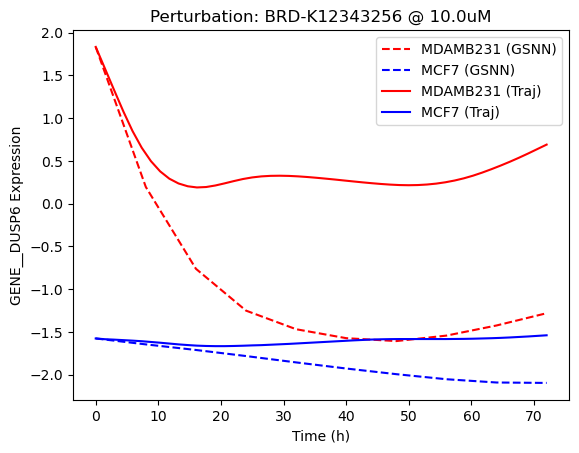

In [17]:
plt.figure()
plt.plot(np.linspace(0,t.max().item(), x1_t_hat.shape[0]), x1_t_hat[:, target_ix].detach().cpu().numpy(), 'r--', label=f'{cell1} (GSNN)')
plt.plot(np.linspace(0,t.max().item(), x2_t_hat.shape[0]), x2_t_hat[:, target_ix].detach().cpu().numpy(), 'b--', label=f'{cell2} (GSNN)')
plt.plot(np.linspace(0,t.max().item(), x1.shape[0]), x1[:, target_ix].detach().cpu().numpy(), 'r-', label=f'{cell1} (Traj)')
plt.plot(np.linspace(0,t.max().item(), x2.shape[0]), x2[:, target_ix].detach().cpu().numpy(), 'b-', label=f'{cell2} (Traj)')
plt.title(f'Perturbation: {drug} @ {dose}uM')
plt.xlabel('Time (h)')
plt.ylabel(f'{target_gene} Expression')
plt.legend()
plt.show()

In [18]:
ode_params = {'t': t, 
              'method': 'euler', 
              'tol': None} 


gsnn_explainer_params = {'hard': False, 
                         'beta': 5e-4, 
                         'lr': 5e-2, 
                         'prior': 5, 
                         'iters': 250, 
                         'entropy': 1., 
                         'grad_norm_clip': 1.0, 
                         'free_edges': 100} 


# CELL1 explanation

In [19]:
# NOTE: we are using the ODE model here

ode_gsnn = ODEWrapper(model, 
                      data, 
                      dxdt_scale, 
                      **ode_params)

explainer = GSNNExplainer(ode_gsnn, 
                          data, 
                          **gsnn_explainer_params)

gsnn_res1 = explainer.explain(x0_1.to(device), target_idx=[target_ix], target='edge')

iter: 249 | loss: 1.4311 | mse: 0.0112 | r2: 0.990 | active edges: 2707 / 43637 | entropy: 0.139697
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 1451 / 43637 (3.3%)
MSE (subset): 0.009196
R² (subset): 0.9916
Variance explained: 0.9932
Correlation: 0.9966


In [20]:
# NOTE: we are using the dxdt model (not the ODE model) this means there won't be the same long distance /temporal dependencies 


explainer = OcclusionExplainer(model.to(device), data)
occlusion_res1 = explainer.explain(x1_t_hat_input.to(device),  
                                   target_idx=target_ix, 
                                   target='edge', 
                                   element_mask=gsnn_res1.score.values > 0.5) 


In [21]:
#explainer = NoiseTunnel(IGExplainer(model.to(device), data), n_samples=10, noise_std=0.1) 
explainer = IGExplainer(model.to(device), data, n_steps=50)

ig_res1 = explainer.explain(x1_t_hat_input.to(device), 
                            target_idx=target_ix, 
                            target='edge', 
                            reduction='sum',
                            element_mask=gsnn_res1.score.values > 0.5)

In [22]:

res1 = gsnn_res1.merge(ig_res1, on=['source', 'target'], how='inner').rename(columns={'score_x': 'gsnn_score', 'score_y': 'ig_score'})
res1 = res1.merge(occlusion_res1, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
res1 = res1.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                   abs_oc_score = lambda x: x.occlusion_score.abs())
res1 = res1[lambda x: x.gsnn_score > 0.5]
#res1 = res1[lambda x: x.occlusion_score.abs() > 0.05]
print(res1.shape)
res1.head(5)

(1451, 7)


,source,target,gsnn_score,ig_score,occlusion_score,abs_ig_score,abs_oc_score
18,PROTEIN__CAMKK2,PROTEIN__PRKAA1_PRKAA2_PRKAB1_PRKAB2_PRKAG1_PR...,0.979816,-0.077603,-0.026863,0.077603,0.026863
39,PROTEIN__TNF,RNA__hsa-miR-181a-5p,0.916443,0.086674,-0.005207,0.086674,0.005207
71,PROTEIN__MINK1,PROTEIN__MAPK14,0.708375,0.045802,0.001267,0.045802,0.001267
103,RNA__CREB1,PROTEIN__CREB1,0.949968,-0.058495,0.010876,0.058495,0.010876
161,PROTEIN__MEF2A,RNA__hsa-miR-200c,0.873759,0.000080,-0.000012,0.000080,0.000012


In [23]:
res1[['ig_score', 'occlusion_score', 'gsnn_score', 'abs_ig_score', 'abs_oc_score']].corr(method='spearman')

,ig_score,occlusion_score,gsnn_score,abs_ig_score,abs_oc_score
ig_score,1.000000,0.708350,-0.051479,-0.063718,-0.101817
occlusion_score,0.708350,1.000000,-0.067635,-0.097799,-0.131192
gsnn_score,-0.051479,-0.067635,1.000000,0.251673,0.236455
abs_ig_score,-0.063718,-0.097799,0.251673,1.000000,0.922840
abs_oc_score,-0.101817,-0.131192,0.236455,0.922840,1.000000


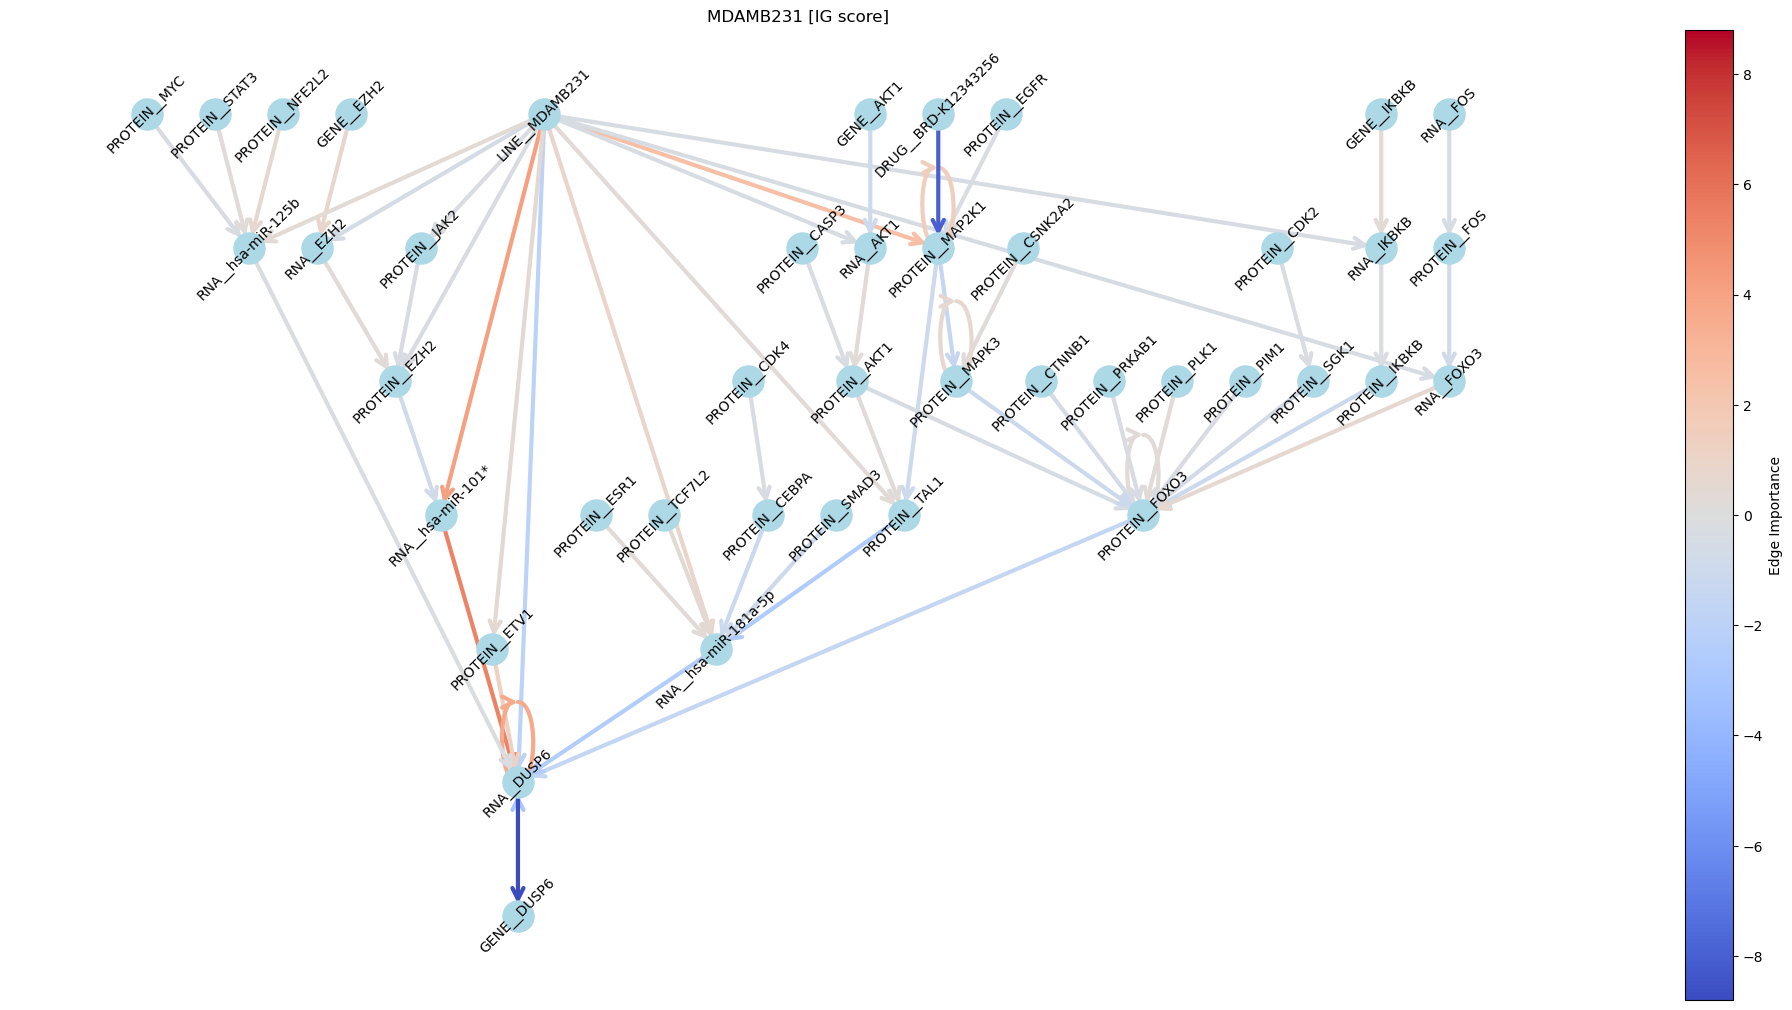

In [24]:
plot_edge_importance(res1.rename(columns={'ig_score': 'score'}).sort_values(by='abs_ig_score', ascending=False).head(150), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell1} [IG score]')

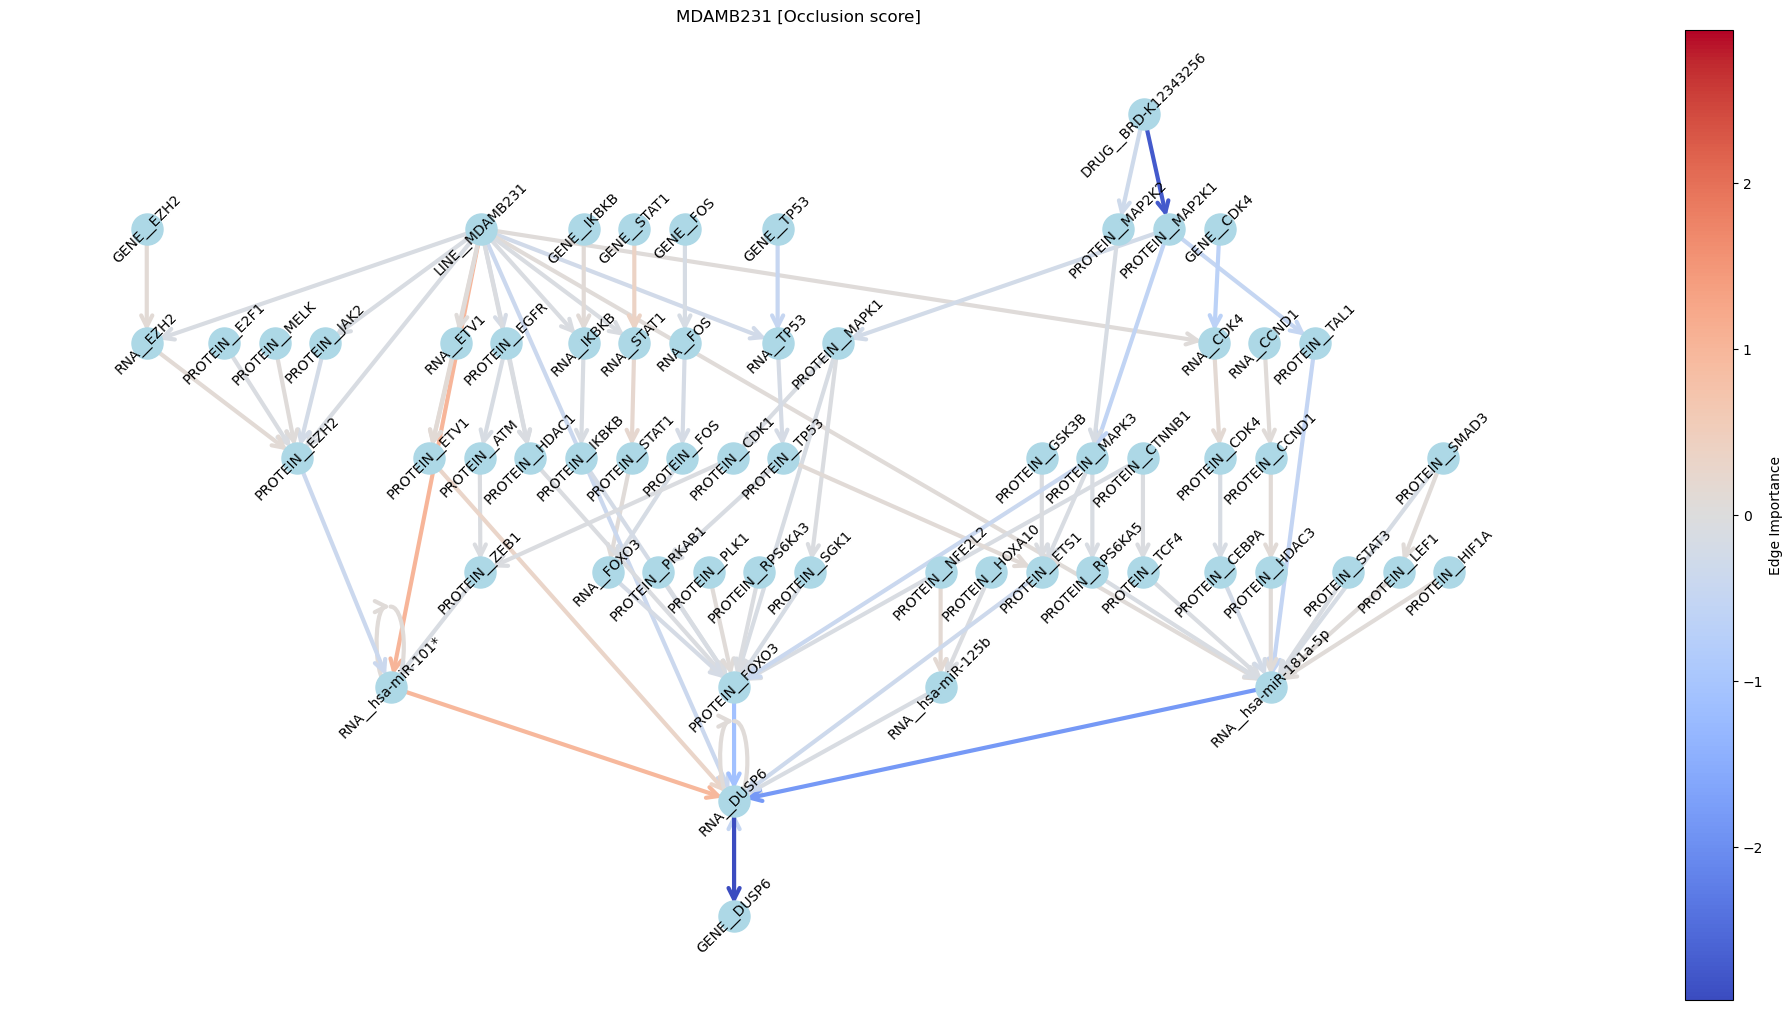

In [25]:
plot_edge_importance(res1.rename(columns={'occlusion_score': 'score'}).sort_values(by='abs_oc_score', ascending=False).head(150), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell1} [Occlusion score]')

In [26]:
G = nx.from_pandas_edgelist(res1, source='source', target='target', create_using=nx.DiGraph)
G_all = nx.from_pandas_edgelist(gsnn_res1, source='source', target='target', create_using=nx.DiGraph)
gene_list = [x.split('__')[1] for x in G.nodes()]
background = [x.split('__')[1] for x in G_all.nodes()]

enr1 = gp.enrichr(gene_list, 'Reactome_2022', background=background, outdir=None)

enr1.res2d.sort_values(by='Adjusted P-value', ascending=True).head(10)[['Term', 'Adjusted P-value']]

,Term,Adjusted P-value
0,Generic Transcription Pathway R-HSA-212436,1.021474e-14
1,Gene Expression (Transcription) R-HSA-74160,1.134685e-13
2,Signaling By Interleukins R-HSA-449147,1.134685e-13
3,RNA Polymerase II Transcription R-HSA-73857,1.785896e-13
4,Cytokine Signaling In Immune System R-HSA-1280215,2.005175e-13
5,Signal Transduction R-HSA-162582,1.034749e-12
6,Cellular Senescence R-HSA-2559583,8.076207e-12
7,Toll Like Receptor 4 (TLR4) Cascade R-HSA-166016,1.601951e-11
8,MyD88:MAL(TIRAP) Cascade Initiated On Plasma M...,3.068135e-11
9,MyD88-independent TLR4 Cascade R-HSA-166166,3.068135e-11


In [27]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res1 = explainer.explain(x1_t_hat_input.to(device), 
                                   target_idx=target_ix, 
                                   target='node')

occlusion_res1.sort_values(by='score', ascending=False).head()

,node,score
1966,RNA__hsa-miR-101*,0.981260
925,PROTEIN__ETV1,0.313091
1262,RNA__STAT1,0.212799
1865,PROTEIN__MAPKAPK2,0.172142
1753,RNA__MAPKAPK2,0.171136


In [28]:
torch.cuda.empty_cache()

explainer = IGExplainer(model.to(device), data, n_steps=50)
ig_res1 = explainer.explain(x1_t_hat_input.to(device), 
                            target_idx=target_ix, 
                            target='node', 
                            reduction='sum')

ig_res1.sort_values(by='score', ascending=False).head() 

,node,score
1966,RNA__hsa-miR-101*,2.833005
925,PROTEIN__ETV1,0.965116
1262,RNA__STAT1,0.629775
1912,PROTEIN__HIF1A,0.445350
1003,PROTEIN__ERBB2,0.443203


# CELL 2 Explanation 

In [29]:

ode_gsnn = ODEWrapper(model, 
                      data, 
                      dxdt_scale, 
                      **ode_params)

explainer = GSNNExplainer(ode_gsnn, 
                          data, 
                          **gsnn_explainer_params)

gsnn_res2 = explainer.explain(x0_2.to(device), target_idx=[target_ix], target='edge')

iter: 249 | loss: 0.7477 | mse: 0.0005 | r2: 0.985 | active edges: 1315 / 43637 | entropy: 0.129557
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 90 / 43637 (0.2%)
MSE (subset): 0.001535
R² (subset): 0.9524
Variance explained: 0.9850
Correlation: 0.9925


In [30]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res2 = explainer.explain(x2_t_hat_input.to(device), 
                                   target_idx=target_ix, 
                                   target='edge', 
                                   element_mask=gsnn_res2.score.values > 0.5) 


In [31]:
explainer = IGExplainer(model.to(device), data)
ig_res2 = explainer.explain(x2_t_hat_input.to(device), 
                            target_idx=target_ix, 
                            target='edge', 
                            reduction='sum',
                            element_mask=gsnn_res2.score.values > 0.5)

In [32]:
res2 = gsnn_res2.merge(ig_res2, on=['source', 'target'], how='inner').rename(columns={'score_x': 'gsnn_score', 'score_y': 'ig_score'})
res2 = res2.merge(occlusion_res2, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
res2 = res2.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                   abs_oc_score = lambda x: x.occlusion_score.abs())
res2 = res2[lambda x: x.gsnn_score > 0.5]
print(res2.shape)
res2.head()

(90, 7)


,source,target,gsnn_score,ig_score,occlusion_score,abs_ig_score,abs_oc_score
245,PROTEIN__SOX2,RNA__hsa-miR-181a-5p,0.987452,-0.054835,-0.062537,0.054835,0.062537
1248,PROTEIN__TAL1,RNA__hsa-miR-181a-5p,0.998143,-2.124796,-0.202972,2.124796,0.202972
1420,RNA__hsa-miR-125b,RNA__DUSP6,0.631593,0.928478,0.160193,0.928478,0.160193
2430,RNA__PTK2,PROTEIN__PTK2,0.972872,-0.016819,0.004478,0.016819,0.004478
3238,RNA__STAT3,PROTEIN__STAT3,0.963894,0.349533,-0.027256,0.349533,0.027256


In [33]:
res2[['ig_score', 'occlusion_score', 'gsnn_score', 'abs_ig_score', 'abs_oc_score']].corr(method='spearman')

,ig_score,occlusion_score,gsnn_score,abs_ig_score,abs_oc_score
ig_score,1.000000,0.777072,-0.128076,-0.099398,-0.111020
occlusion_score,0.777072,1.000000,-0.104136,-0.096022,-0.302564
gsnn_score,-0.128076,-0.104136,1.000000,0.520427,0.472527
abs_ig_score,-0.099398,-0.096022,0.520427,1.000000,0.738251
abs_oc_score,-0.111020,-0.302564,0.472527,0.738251,1.000000


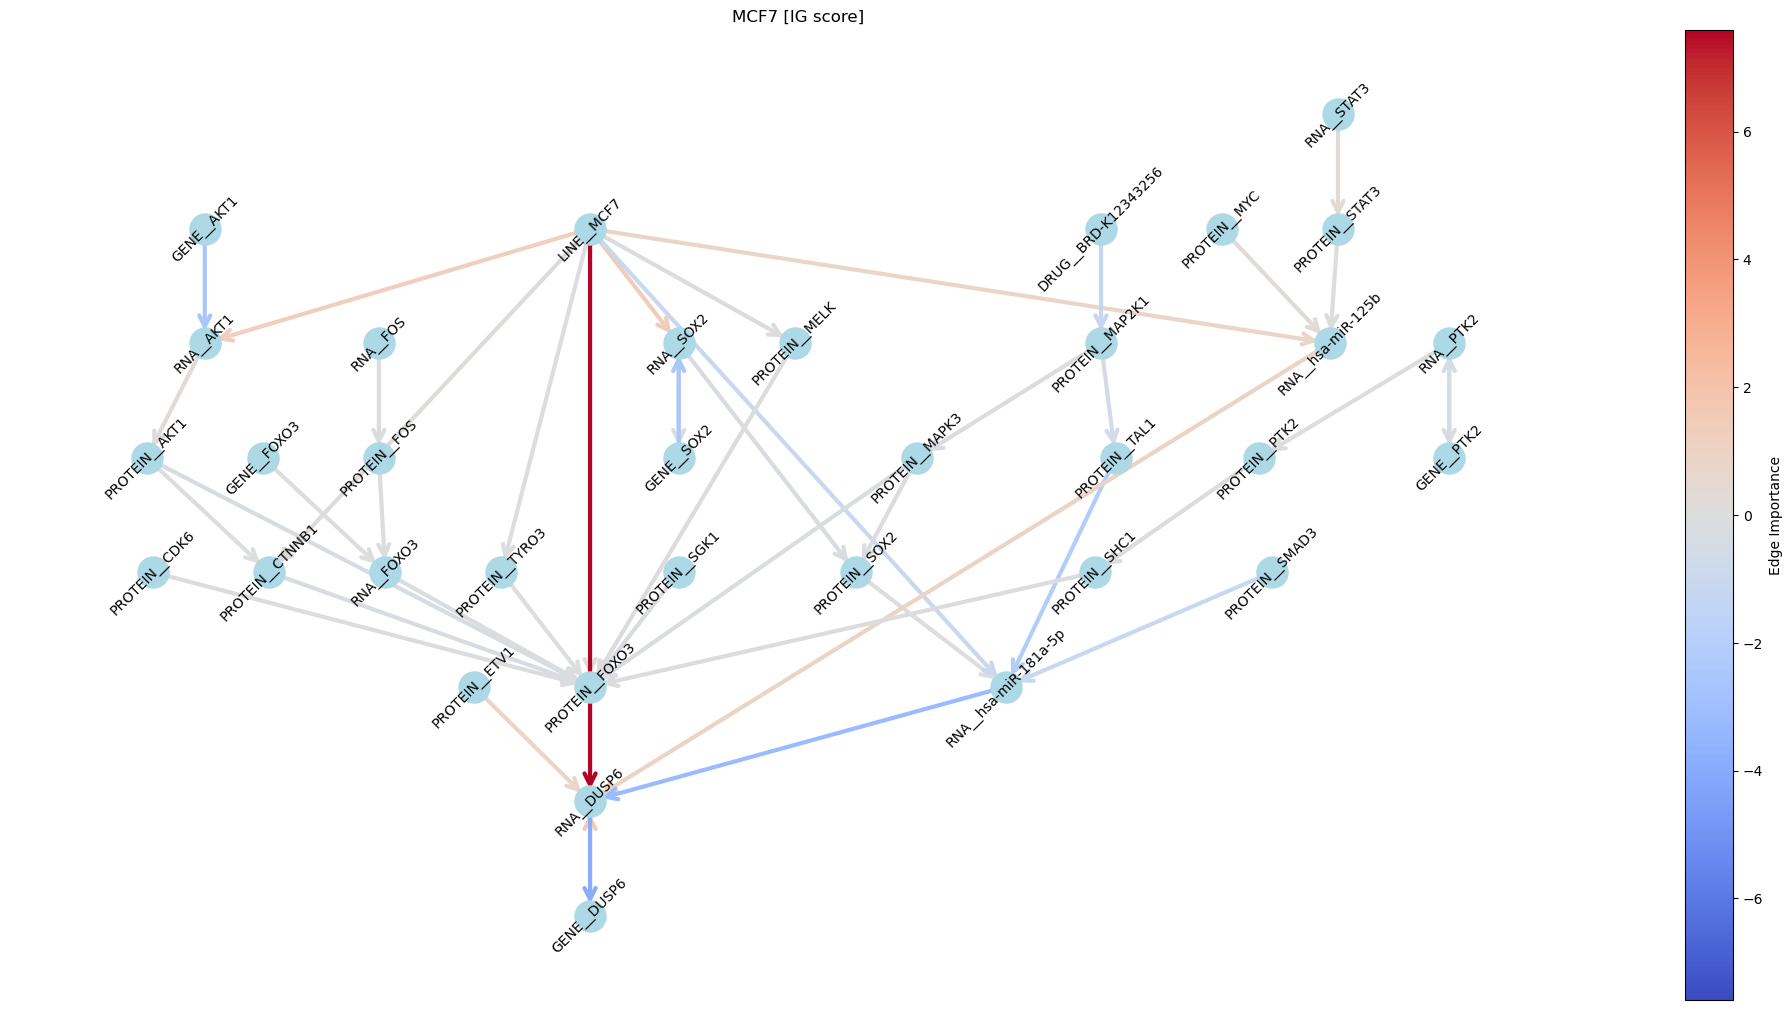

In [34]:
plot_edge_importance(res2.rename(columns={'ig_score': 'score'}), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell2} [IG score]')

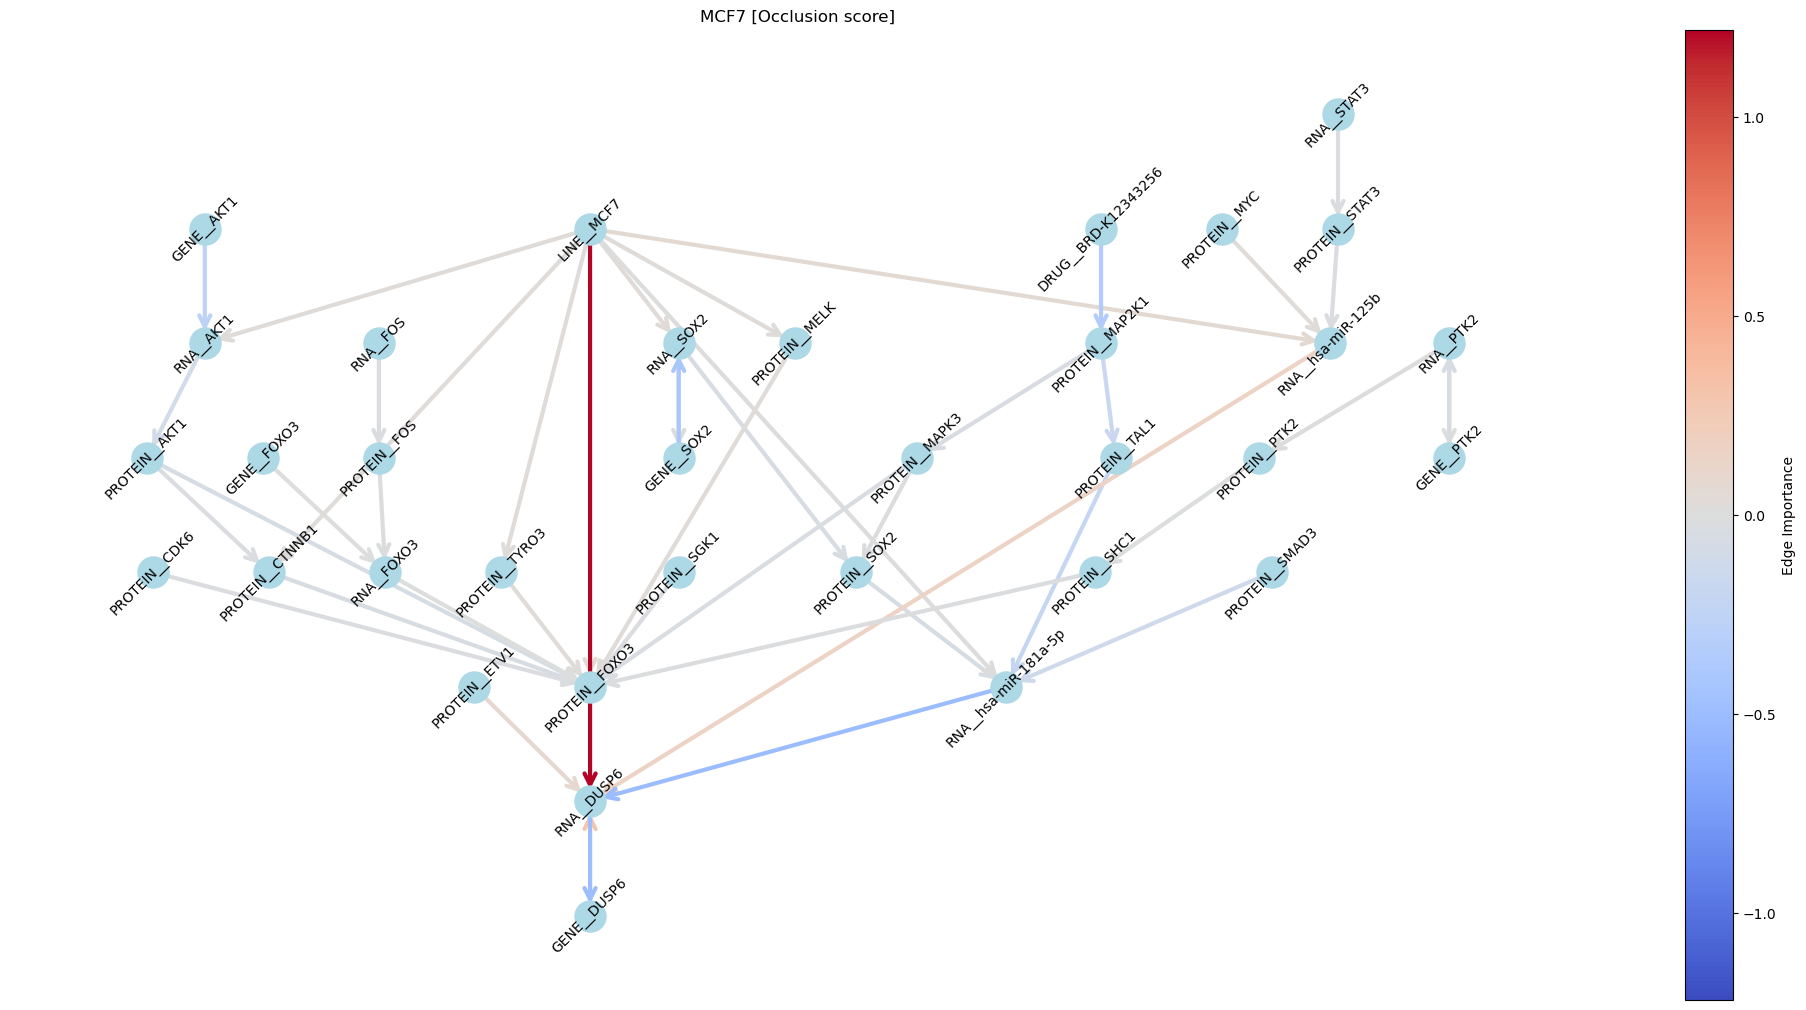

In [35]:
plot_edge_importance(res2.rename(columns={'occlusion_score': 'score'}), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell2} [Occlusion score]')

In [36]:
G = nx.from_pandas_edgelist(res2, source='source', target='target', create_using=nx.DiGraph)
G_all = nx.from_pandas_edgelist(gsnn_res2, source='source', target='target', create_using=nx.DiGraph)
gene_list = [x.split('__')[1] for x in G.nodes()]
background = [x.split('__')[1] for x in G_all.nodes()]

enr2 = gp.enrichr(gene_list, 'Reactome_2022', background=background, outdir=None)

enr2.res2d.sort_values(by='Adjusted P-value', ascending=True).head(5)[['Term', 'Adjusted P-value']]

,Term,Adjusted P-value
0,Signaling By Interleukins R-HSA-449147,8.489001e-08
1,Senescence-Associated Secretory Phenotype (SAS...,8.489001e-08
2,Extra-nuclear Estrogen Signaling R-HSA-9009391,1.654284e-07
4,Cytokine Signaling In Immune System R-HSA-1280215,4.443171e-07
3,Developmental Biology R-HSA-1266738,4.443171e-07


In [37]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res2 = explainer.explain(x2_t_hat_input.to(device), 
                                   target_idx=target_ix, 
                                   target='node')

occlusion_res2.sort_values(by='score', ascending=False).head()

,node,score
188,RNA__hsa-miR-125b,0.160259
925,PROTEIN__ETV1,0.076890
1966,RNA__hsa-miR-101*,0.050314
558,RNA__ETV1,0.043755
277,PROTEIN__CSNK2A2,0.041516


In [38]:
explainer = IGExplainer(model.to(device), data)
ig_res2 = explainer.explain(x2_t_hat_input.to(device), 
                            target_idx=target_ix, 
                            target='node', 
                            reduction='sum')

ig_res2.sort_values(by='score', ascending=False).head()

,node,score
924,RNA__DUSP6,1.255535
188,RNA__hsa-miR-125b,0.679335
925,PROTEIN__ETV1,0.267948
1966,RNA__hsa-miR-101*,0.191333
558,RNA__ETV1,0.165915


# comparing GSEA results between CELL 1 and CELL 2 

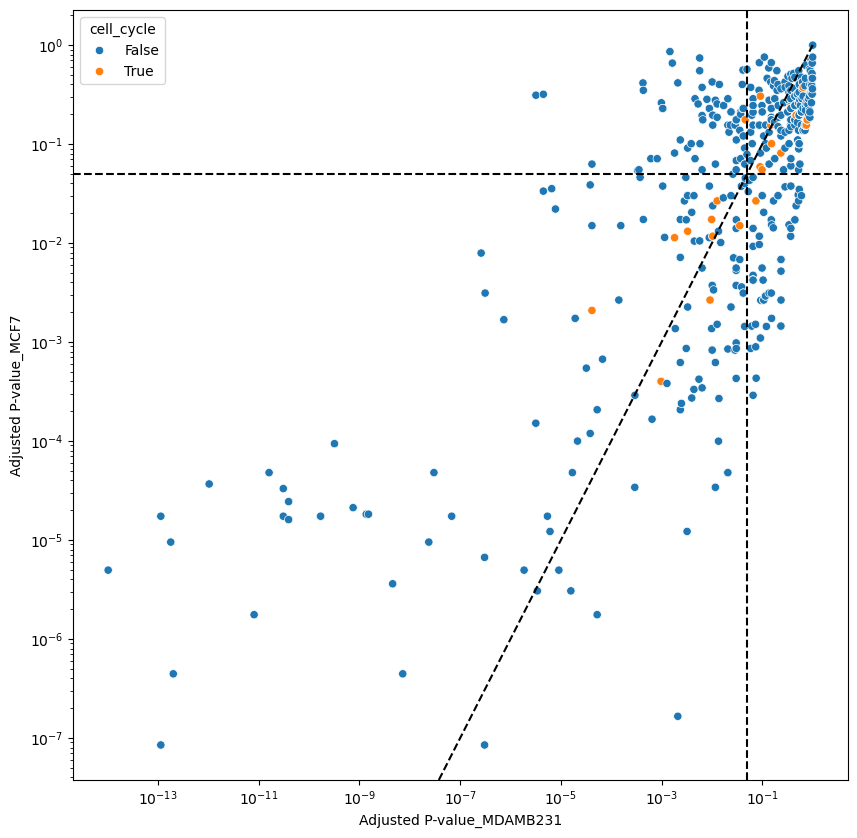

In [39]:
enr = enr1.res2d.merge(enr2.res2d, on='Term', how='inner')
enr = enr.rename(columns={'Adjusted P-value_x': f'Adjusted P-value_{cell1}', 'Adjusted P-value_y': f'Adjusted P-value_{cell2}'})
enr = enr.assign(cell_cycle = lambda x: x.Term.str.lower().str.contains('cell cycle') | x.Term.str.contains('G1'))

plt.figure(figsize=(10, 10))
sbn.scatterplot(data=enr, x=f'Adjusted P-value_{cell1}', y=f'Adjusted P-value_{cell2}', hue='cell_cycle')
plt.plot([0, 1], [0, 1], 'k--')
plt.xscale('log')
plt.yscale('log')

plt.axvline(0.05, color='k', linestyle='--')
plt.axhline(0.05, color='k', linestyle='--')


# add text labels to outliers (those that are not similar between the two cells)
'''for i, row in enr.iterrows():
    cell1_log_pval = np.log10(row[f'Adjusted P-value_{cell1}'])
    cell2_log_pval = np.log10(row[f'Adjusted P-value_{cell2}'])
    diff = np.abs(cell1_log_pval - cell2_log_pval)
    if diff > 2.5:
        plt.text(row[f'Adjusted P-value_{cell1}'], row[f'Adjusted P-value_{cell2}'], row['Term'], fontsize=12)'''

plt.show()

In [40]:
enr = enr.assign(diff_log_pval = lambda x: np.abs(np.log10(x[f'Adjusted P-value_{cell1}']) - np.log10(x[f'Adjusted P-value_{cell2}'])))
enr = enr[['Term', 'Adjusted P-value_MCF7', 'Adjusted P-value_MDAMB231', 'diff_log_pval']].sort_values(by='diff_log_pval', ascending=False)
enr[lambda x: x.Term.str.contains('MAPK')].head(10)

,Term,Adjusted P-value_MCF7,Adjusted P-value_MDAMB231,diff_log_pval
158,MAP2K And MAPK Activation R-HSA-5674135,0.000048,2.066320e-02,2.634991
22,MAPK Targets/ Nuclear Events Mediated By MAP K...,0.000010,2.380240e-08,2.601789
91,MAPK Family Signaling Cascades R-HSA-5683057,0.000012,3.200404e-03,2.419368
148,Oncogenic MAPK Signaling R-HSA-6802957,0.000099,1.346859e-02,2.131518
43,ERK/MAPK Targets R-HSA-198753,0.001732,1.919063e-05,1.955344
150,MAPK1/MAPK3 Signaling R-HSA-5684996,0.000269,1.374900e-02,1.708981
293,Negative Regulation Of MAPK Pathway R-HSA-5675221,0.002652,1.064210e-01,1.603522
299,Signaling By MAPK Mutants R-HSA-9652817,0.002912,1.156664e-01,1.598950
367,GRB2:SOS Provides Linkage To MAPK Signaling Fo...,0.006809,2.345086e-01,1.537104
419,MAPK6/MAPK4 Signaling R-HSA-5687128,0.014032,3.687310e-01,1.419590


In [41]:
enr.sort_values(by='Adjusted P-value_MCF7', ascending=True).head(10)

,Term,Adjusted P-value_MCF7,Adjusted P-value_MDAMB231,diff_log_pval
26,Senescence-Associated Secretory Phenotype (SAS...,8.489001e-08,3.048055e-07,0.555166
2,Signaling By Interleukins R-HSA-449147,8.489001e-08,1.134685e-13,5.873981
80,Extra-nuclear Estrogen Signaling R-HSA-9009391,1.654284e-07,2.095626e-03,4.102704
4,Cytokine Signaling In Immune System R-HSA-1280215,4.443171e-07,2.005175e-13,6.345541
21,Developmental Biology R-HSA-1266738,4.443171e-07,7.226296e-09,1.788777
6,Cellular Senescence R-HSA-2559583,1.758178e-06,8.076207e-12,5.337856
51,Estrogen-dependent Nuclear Events Downstream O...,1.758178e-06,5.242339e-05,1.474462
41,Signaling By NTRK1 (TRKA) R-HSA-187037,3.059302e-06,1.575606e-05,0.711825
33,ESR-mediated Signaling R-HSA-8939211,3.059302e-06,3.401496e-06,0.046048
20,Signaling By Receptor Tyrosine Kinases R-HSA-9...,3.608035e-06,4.555769e-09,2.898709


# Contrastive Explanation 

In [42]:
ode_gsnn = ODEWrapper(model, 
                      data, 
                      dxdt_scale, 
                      **ode_params)
                      

explainer = ContrastiveGSNNExplainer(ode_gsnn, 
                                     data,
                                     hard=False,
                                     beta=5e-4,
                                     lr=1e-1,
                                     prior=5,
                                     iters=250,
                                     free_edges=100)

                                     
cres_gsnn = explainer.explain(x0_1.to(device), 
                              x0_2.to(device), 
                              target_idx=target_ix, 
                              target='edge')

cres_gsnn.head()

Batch size: 1, Target dims: 1
Target Δf mean: 0.985540, std: 0.959611
iter: 249 | loss: 1.2683 | mse: 0.0548 | r2: 0.934 | active edges: 2053 / 43637 | entropy: 0.12901
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 811 / 43637 (1.9%)
Target Δf mean: 0.985540
Subset Δf mean: 1.041554
MSE: 0.009320
R² (across 1x1 elements): 0.9888


,source,target,score
0,PROTEIN__IL4R,PROTEIN__JAK1,0.029114
1,PROTEIN__IL4R,PROTEIN__JAK3,0.026360
2,PROTEIN__IL4R,PROTEIN__JAK2,0.049986
3,PROTEIN__IL4R,PROTEIN__STAT5A,0.017411
4,RNA__hsa-let-7c-3p,RNA__HMGA2,0.021038


In [43]:
explainer = ContrastiveIGExplainer(model.to(device), data)

cres_ig = explainer.explain(x1_t_hat_input.to(device), 
                            x2_t_hat_input.to(device), 
                            target_idx=target_ix, 
                            element_mask=cres_gsnn.score.values > 0.5,
                            target='edge')

cres_ig.sort_values(by='score', ascending=False).head()


,source,target,score
40747,RNA__DUSP6,GENE__DUSP6,1.220687
16742,GENE__ABL1,RNA__ABL1,1.031658
17215,GENE__SOX2,RNA__SOX2,0.785567
17532,DRUG__BRD-K12343256,PROTEIN__MAP2K1,0.630019
8804,RNA__hsa-miR-181a-5p,RNA__DUSP6,0.393944


In [44]:

explainer = ContrastiveOcclusionExplainer(model.to(device), data)
cres_occ = explainer.explain(x1_t_hat_input.to(device), 
                             x2_t_hat_input.to(device), 
                             target_idx=target_ix, 
                             element_mask=cres_gsnn.score.values > 0.5,
                             target='edge')

cres_occ.head()

,source,target,score
0,PROTEIN__IL4R,PROTEIN__JAK1,NaN
1,PROTEIN__IL4R,PROTEIN__JAK3,NaN
2,PROTEIN__IL4R,PROTEIN__JAK2,NaN
3,PROTEIN__IL4R,PROTEIN__STAT5A,NaN
4,RNA__hsa-let-7c-3p,RNA__HMGA2,NaN


In [45]:
cres = cres_ig.merge(cres_gsnn, on=['source', 'target'], how='inner').rename(columns={'score_x': 'ig_score', 'score_y': 'gsnn_score'})
cres = cres.merge(cres_occ, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
cres = cres.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                   abs_oc_score = lambda x: x.occlusion_score.abs())
cres = cres[lambda x: x.gsnn_score > 0.5]
cres.head() 

,source,target,ig_score,gsnn_score,occlusion_score,abs_ig_score,abs_oc_score
39,PROTEIN__TNF,RNA__hsa-miR-181a-5p,-4.876927e-03,0.852106,8.539563e-03,4.876927e-03,8.539563e-03
103,RNA__CREB1,PROTEIN__CREB1,-5.626472e-04,0.989377,1.272302e-02,5.626472e-04,1.272302e-02
166,PROTEIN__CCNA1,PROTEIN__E2F1,7.669387e-03,0.995502,5.064774e-02,7.669387e-03,5.064774e-02
225,PROTEIN__SOX2,RNA__ETV1,7.016511e-03,0.979226,3.213368e-02,7.016511e-03,3.213368e-02
238,PROTEIN__SOX2,RNA__hsa-miR-124-5p,9.432096e-08,0.930229,9.924173e-07,9.432096e-08,9.924173e-07


In [46]:
cres[lambda x: x.source.str.contains('RAS') | x.target.str.contains('RAS')].sort_values(by='ig_score', ascending=False).head(5)

,source,target,ig_score,gsnn_score,occlusion_score,abs_ig_score,abs_oc_score


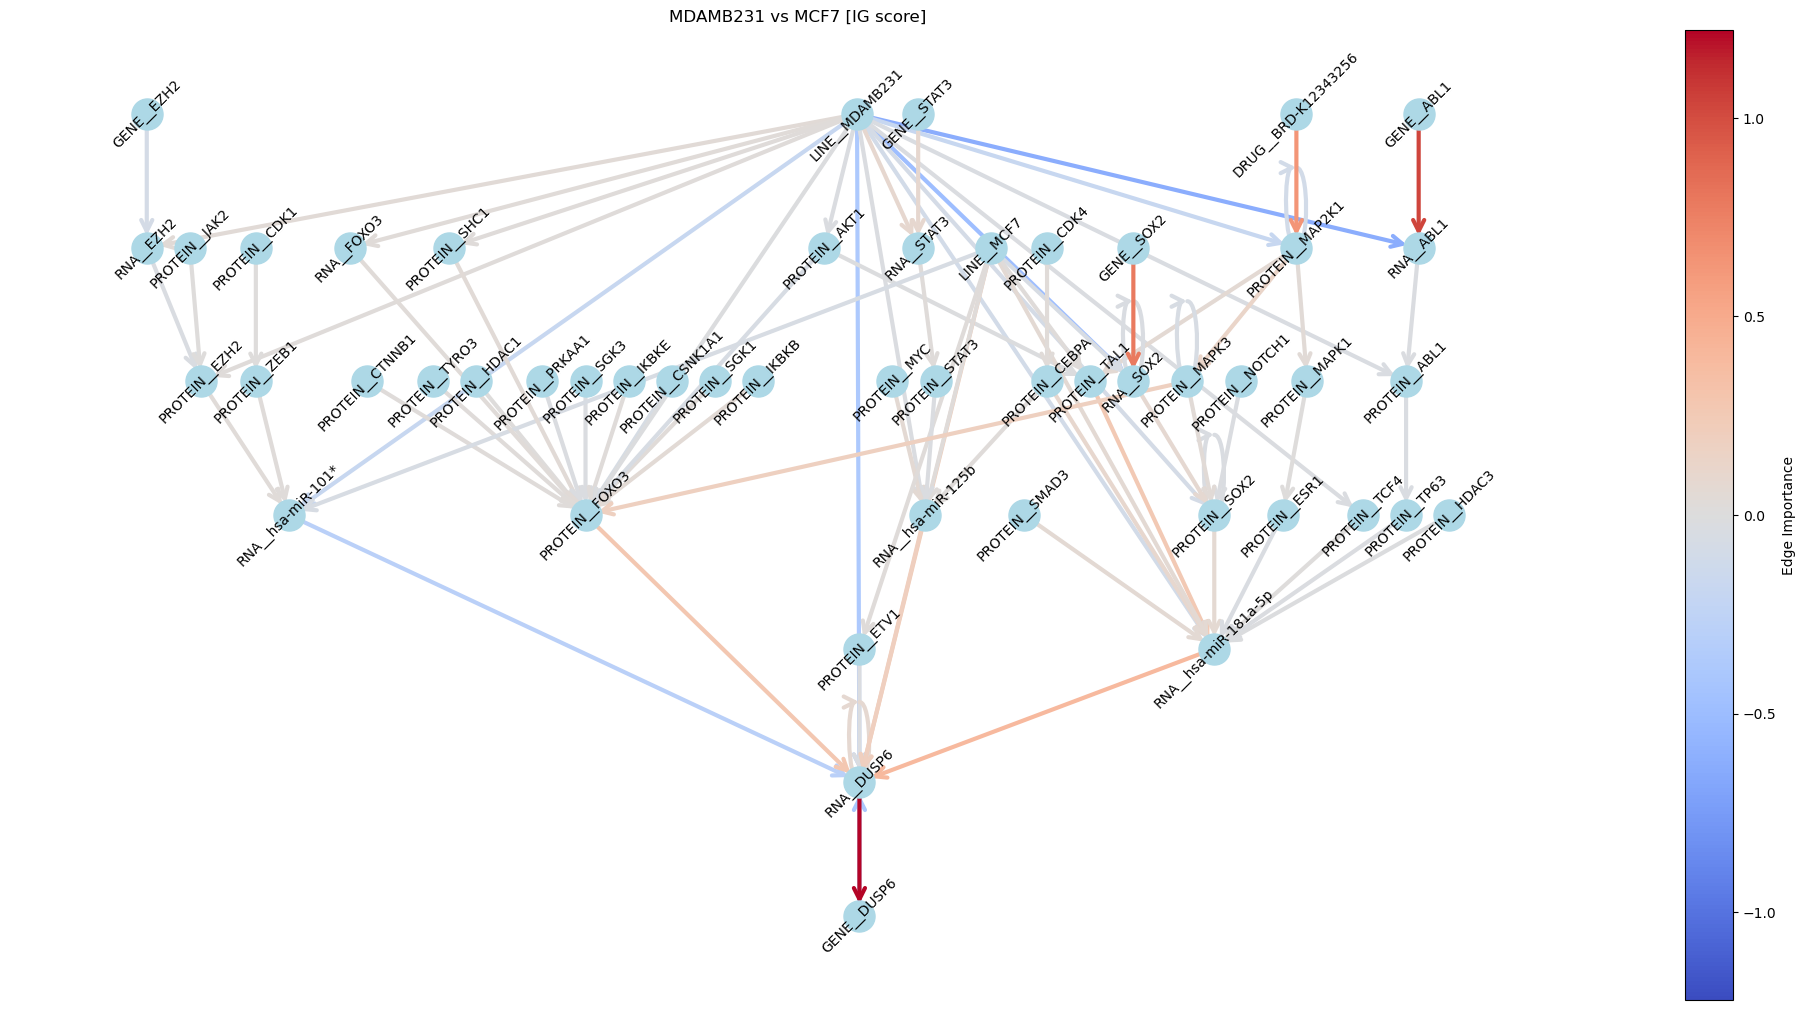

In [47]:
plot_edge_importance(cres.rename(columns={'ig_score': 'score'}).sort_values(by='abs_ig_score', ascending=False).head(150), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell1} vs {cell2} [IG score]')

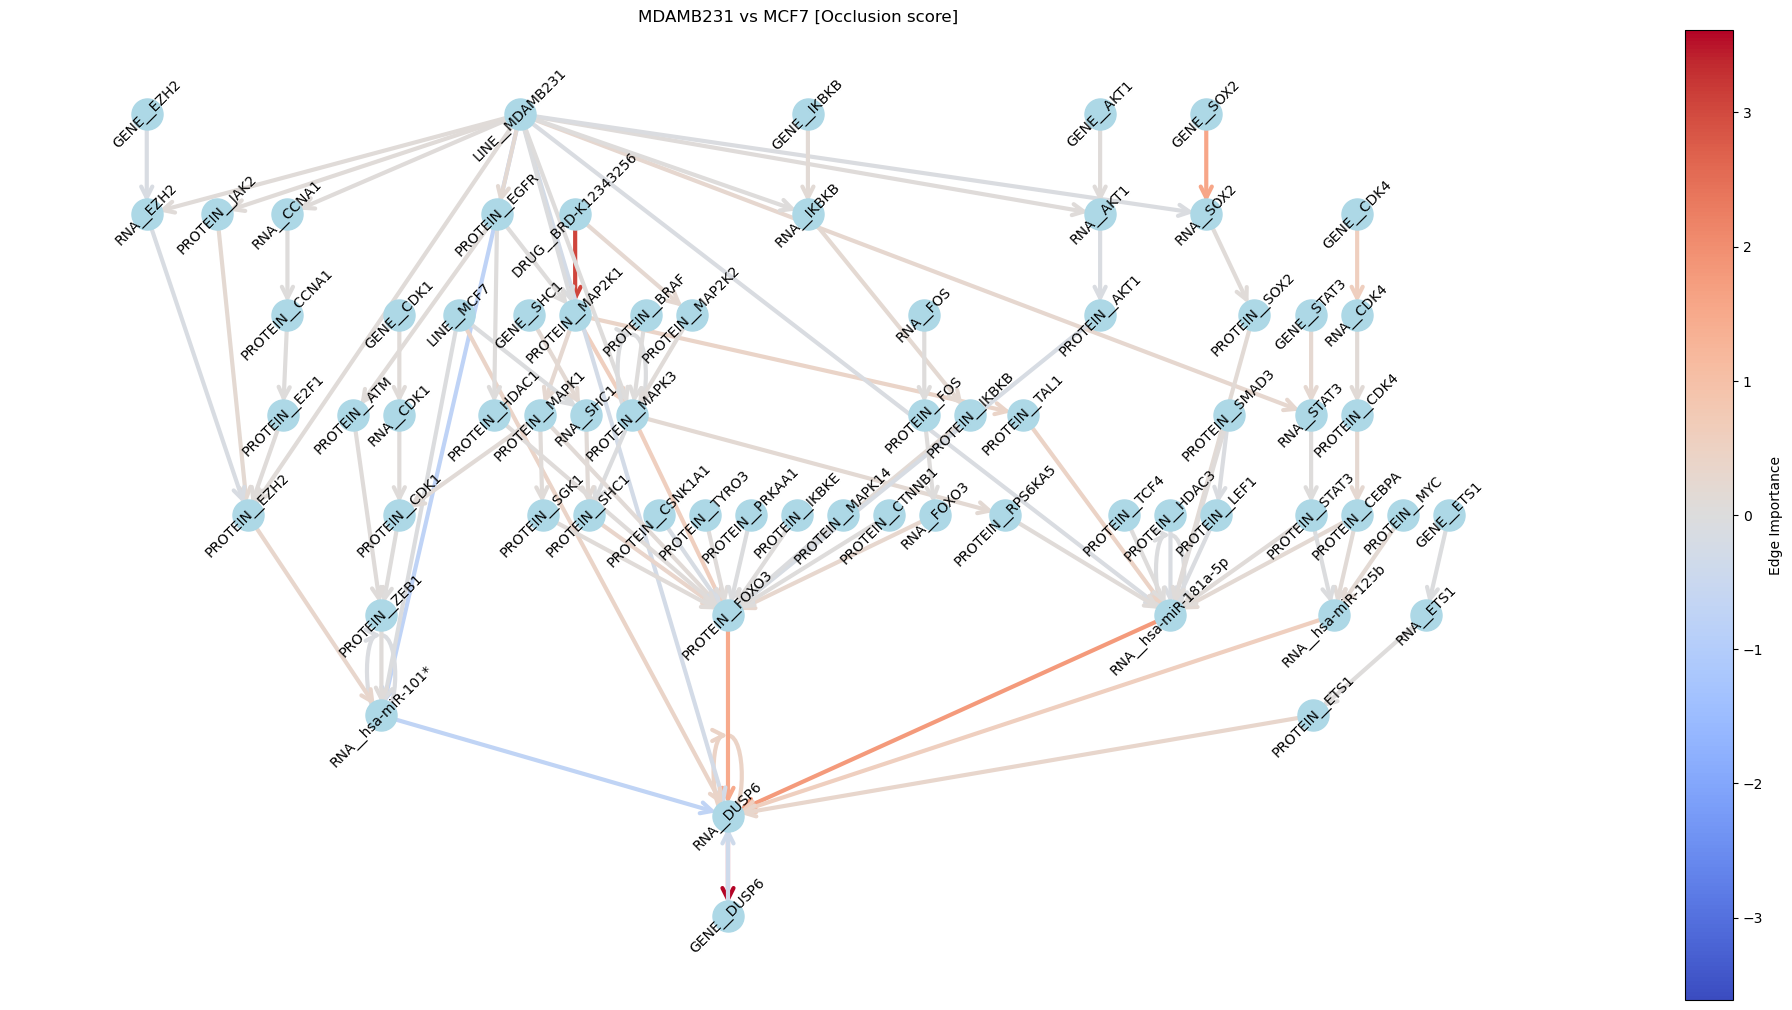

In [48]:
plot_edge_importance(cres.rename(columns={'occlusion_score': 'score'}).sort_values(by='abs_oc_score', ascending=False).head(150), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell1} vs {cell2} [Occlusion score]')

In [49]:
cres[lambda x: x.source == f'LINE__{cell1}'].sort_values(by='ig_score', ascending=False).head(5)

,source,target,ig_score,gsnn_score,occlusion_score,abs_ig_score,abs_oc_score
31316,LINE__MDAMB231,RNA__IGF1R,0.092312,0.999402,0.015065,0.092312,0.015065
31629,LINE__MDAMB231,RNA__STAT3,0.090931,0.999469,0.256602,0.090931,0.256602
31628,LINE__MDAMB231,RNA__STAT1,0.077254,0.999388,0.063507,0.077254,0.063507
31546,LINE__MDAMB231,RNA__RB1,0.075719,0.999725,0.057107,0.075719,0.057107
31069,LINE__MDAMB231,RNA__BTK,0.059199,0.983453,0.018021,0.059199,0.018021


In [50]:
cres[lambda x: x.source == f'LINE__{cell1}'].sort_values(by='ig_score', ascending=False).tail(5)

,source,target,ig_score,gsnn_score,occlusion_score,abs_ig_score,abs_oc_score
31747,LINE__MDAMB231,RNA__hsa-miR-101*,-0.183409,0.999967,-0.745458,0.183409,0.745458
30514,LINE__MDAMB231,PROTEIN__MAP2K1,-0.189099,0.999832,-0.048830,0.189099,0.048830
31198,LINE__MDAMB231,RNA__DUSP6,-0.388068,0.999984,-0.256166,0.388068,0.256166
31609,LINE__MDAMB231,RNA__SOX2,-0.487320,0.999957,-0.057013,0.487320,0.057013
31002,LINE__MDAMB231,RNA__ABL1,-0.624845,0.999909,-0.430476,0.624845,0.430476


In [51]:
cres[lambda x: x.source == f'LINE__{cell2}'].sort_values(by='ig_score', ascending=False).head(5)

,source,target,ig_score,gsnn_score,occlusion_score,abs_ig_score,abs_oc_score
29147,LINE__MCF7,RNA__DUSP6,0.229292,0.999991,0.421571,0.229292,0.421571
29799,LINE__MCF7,RNA__hsa-miR-181a-5p,0.058070,0.999284,0.016611,0.058070,0.016611
29034,LINE__MCF7,RNA__CASP3,0.037398,0.999920,-0.018498,0.037398,0.018498
29265,LINE__MCF7,RNA__IGF1R,0.034865,0.993185,-0.006714,0.034865,0.006714
28964,LINE__MCF7,RNA__AKT1,0.031455,0.999840,-0.006336,0.031455,0.006336


In [52]:
cres[lambda x: x.source == f'LINE__{cell2}'].sort_values(by='ig_score', ascending=False).tail(5)

,source,target,ig_score,gsnn_score,occlusion_score,abs_ig_score,abs_oc_score
28951,LINE__MCF7,RNA__ABL1,-0.016292,0.999707,-0.005268,0.016292,0.005268
29063,LINE__MCF7,RNA__CDK2,-0.017285,0.994122,-0.011847,0.017285,0.011847
29534,LINE__MCF7,RNA__SHC1,-0.046998,0.991904,-0.046436,0.046998,0.046436
29558,LINE__MCF7,RNA__SOX2,-0.050498,0.976243,0.027264,0.050498,0.027264
29696,LINE__MCF7,RNA__hsa-miR-101*,-0.051976,0.757947,-0.039057,0.051976,0.039057


In [53]:
G = nx.from_pandas_edgelist(cres, source='source', target='target', create_using=nx.DiGraph)
G_all = nx.from_pandas_edgelist(cres_gsnn, source='source', target='target', create_using=nx.DiGraph)
gene_list = [x.split('__')[1] for x in G.nodes()]
background = [x.split('__')[1] for x in G_all.nodes()]

enr1 = gp.enrichr(gene_list, 'Reactome_2022', background=background, outdir=None)

enr1.res2d.sort_values(by='Adjusted P-value', ascending=True)[lambda x: x.Term.str.contains('MAPK')].head(20)[['Term', 'Adjusted P-value']].style.hide()

Term,Adjusted P-value
MAPK Targets/ Nuclear Events Mediated By MAP Kinases R-HSA-450282,0.000000
ERK/MAPK Targets R-HSA-198753,0.000030
Negative Feedback Regulation Of MAPK Pathway R-HSA-5674499,0.000430
Gastrin-CREB Signaling Pathway Via PKC And MAPK R-HSA-881907,0.001085
RAF-independent MAPK1/3 Activation R-HSA-112409,0.001085
MAP2K And MAPK Activation R-HSA-5674135,0.002134
FCERI Mediated MAPK Activation R-HSA-2871796,0.002760
Oncogenic MAPK Signaling R-HSA-6802957,0.008414
MAPK Family Signaling Cascades R-HSA-5683057,0.034263
MAPK3 (ERK1) Activation R-HSA-110056,0.034263


In [54]:
explainer = ContrastiveIGExplainer(model.to(device), data)

cres_ig = explainer.explain(x1_t_hat_input.to(device), 
                            x2_t_hat_input.to(device), 
                            target_idx=target_ix, 
                            target='node')

explainer = ContrastiveOcclusionExplainer(model.to(device), data)
cres_occ = explainer.explain(x1_t_hat_input.to(device), 
                             x2_t_hat_input.to(device), 
                             target_idx=target_ix, 
                             target='node')


cres_node = cres_ig.merge(cres_occ, on=['node'], how='inner').rename(columns={'score_x': 'ig_score', 'score_y': 'occlusion_score'})
cres_node = cres_node.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                             abs_oc_score = lambda x: x.occlusion_score.abs())

cres_node.sort_values(by='abs_ig_score', ascending=False).head(15)[['node', 'ig_score', 'occlusion_score']]


,node,ig_score,occlusion_score
924,RNA__DUSP6,1.558420,3.613721
589,PROTEIN__FOXO3,0.298754,1.486776
1304,RNA__hsa-miR-181a-5p,0.296334,1.792683
1966,RNA__hsa-miR-101*,-0.243147,-0.712706
2046,PROTEIN__MAP2K1,0.211621,1.581928
157,PROTEIN__TAL1,0.198966,0.456827
188,RNA__hsa-miR-125b,0.195675,0.592359
2116,PROTEIN__MAPK3,0.176804,0.954249
633,PROTEIN__CEBPA,0.141297,0.329443
1307,PROTEIN__MAPK1,0.126914,0.531778


In [55]:
G = nx.from_pandas_edgelist(cres[lambda x: x.gsnn_score > 0.5],
                            source='source', 
                            target='target', 
                            create_using=nx.DiGraph, 
                            edge_attr='ig_score')

centrality = nx.betweenness_centrality(G)
centrality = pd.Series(centrality, index=G.nodes())

centrality.sort_values(ascending=False).head(25)

PROTEIN__STAT3          0.090152
PROTEIN__TP53           0.067709
PROTEIN__ABL1           0.056403
RNA__STAT3              0.055519
RNA__ABL1               0.050992
RNA__TP53               0.043320
PROTEIN__MAPK1          0.032072
PROTEIN__RELA           0.030229
PROTEIN__PRKCA          0.028629
PROTEIN__SMAD3          0.027571
RNA__hsa-miR-34c-3p     0.027452
PROTEIN__EGFR           0.026802
PROTEIN__SOX2           0.025147
PROTEIN__FOXO3          0.024846
PROTEIN__MAPK3          0.024529
RNA__SOX2               0.024028
RNA__hsa-miR-181a-5p    0.023645
RNA__PIN1               0.019568
RNA__FOS                0.019076
RNA__CDK2               0.017846
PROTEIN__PIN1           0.017533
PROTEIN__FOS            0.017034
PROTEIN__CEBPA          0.016895
PROTEIN__MAP2K1         0.015851
PROTEIN__CDK2           0.015811
dtype: float64

# Counterfactual explanation 

What gene expression could we change to "resensitize" (measured by decrease is DUSP6) to Trametinib? 



In [56]:
from gsnn.interpret.CounterfactualExplainer import CounterfactualExplainer 

In [57]:
gene_input_mask = torch.tensor([1 if 'GENE__' in x else 0 for x in data.node_names_dict['input']], dtype=torch.float32)

explainer = CounterfactualExplainer(model, data)

cf_res = explainer.explain(x0_2.to(device), 
                           target_value= -1,  # we want d(DUSP6)/dt to be negative 
                           target_idx = target_ix, 
                           trainable_mask = gene_input_mask, 
                           lr = 1e-1, 
                           weight_decay = 0.01, 
                           dropout = 0.5, 
                           min_iter= 50, 
                           max_iter = 1000, 
                           tolerance = 1e-5, 
                           verbose=True) 

cf_res.assign(abs_perturbation = lambda x: x.perturbation.abs()).sort_values(by = 'abs_perturbation', ascending=False).head(10)

,feature,original,perturbation,counterfactual,abs_perturbation
721,GENE__STAT3,0.256592,-0.878176,-0.621584,0.878176
303,GENE__GATA2,0.429443,-0.854765,-0.425322,0.854765
441,GENE__ATF1,0.703125,-0.830407,-0.127282,0.830407
404,GENE__KIT,-0.534180,-0.739464,-1.273644,0.739464
276,GENE__ABL1,0.232300,-0.738660,-0.506360,0.738660
623,GENE__PTPN1,0.095642,0.673033,0.768675,0.673033
21,GENE__CDK4,0.842285,0.567225,1.409510,0.567225
524,GENE__PIN1,-0.399902,0.534920,0.135017,0.534920
132,GENE__CREB1,1.107422,-0.513246,0.594176,0.513246
232,GENE__FOXO3,1.029297,0.501543,1.530840,0.501543


In [58]:
# results above suggest that inhibition of CREB1 is the most effective way to "resensitize" MCF7 cells to Trametinib 


In [59]:
gene_input_mask = torch.tensor([1 if 'LINE__' in x else 0 for x in data.node_names_dict['input']], dtype=torch.float32)

explainer = CounterfactualExplainer(model, data)

cf_res = explainer.explain(x0_2.to(device), 
                           target_value= -1,  # we want d(DUSP6)/dt to be negative 
                           target_idx = target_ix, 
                           trainable_mask = gene_input_mask, 
                           lr = 1e-1, 
                           weight_decay = 0.0, 
                           dropout = 0., 
                           min_iter= 50, 
                           max_iter = 1000, 
                           tolerance = 1e-5, 
                           verbose=True) 
                           #transform = lambda x: torch.nn.functional.softmax(x, dim=1)) 

cf_res.assign(abs_perturbation = lambda x: x.perturbation.abs()).sort_values(by = 'abs_perturbation', ascending=False).head(10)

Iteration 65: Loss = 0.000011
Converged at iteration 65
Final loss: 0.000011


,feature,original,perturbation,counterfactual,abs_perturbation
993,LINE__HS578T,0.0,0.776152,0.776152,0.776152
991,LINE__BT20,0.0,-0.752763,-0.752763,0.752763
996,LINE__MDAMB231,0.0,0.547317,0.547317,0.547317
999,LINE__T47D,0.0,0.513540,0.513540,0.513540
992,LINE__BT474,0.0,-0.499689,-0.499689,0.499689
1000,LINE__ZR751,0.0,-0.486291,-0.486291,0.486291
994,LINE__MCF10A,0.0,0.432892,0.432892,0.432892
995,LINE__MCF7,1.0,-0.390959,0.609041,0.390959
998,LINE__SKBR3,0.0,-0.369850,-0.369850,0.369850
997,LINE__MDAMB468,0.0,0.324748,0.324748,0.324748


In [60]:
drug_input_mask = torch.tensor([1 if ('DRUG__' in x and (x != 'DRUG__BRD-K12343256')) else 0 for x in data.node_names_dict['input']], dtype=torch.float32)

explainer = CounterfactualExplainer(model, data)

cf_res = explainer.explain(x0_2.to(device), 
                           target_value= -5,  # we want d(DUSP6)/dt to be negative (decreasing expression at t=0)
                           target_idx = target_ix, 
                           trainable_mask = drug_input_mask, 
                           lr = 1e-1, 
                           weight_decay = 0.0001, 
                           dropout = 0.1, 
                           min_iter= 250, 
                           max_iter = 1000, 
                           tolerance = 1e-5, 
                           verbose=True,
                           transform = lambda x: torch.nn.functional.softmax(x, dim=1)) 
                           #transform = lambda x: torch.nn.functional.gumbel_softmax(x, dim=1, hard=True, tau=1.0)) 

cf_res.assign(abs_perturbation = lambda x: x.perturbation.abs()).sort_values(by = 'abs_perturbation', ascending=False).head(10)

,feature,original,perturbation,counterfactual,abs_perturbation
985,DRUG__BRD-K44227013,0.000000,0.234570,0.234570,0.234570
989,DRUG__BRD-M07438658,0.000000,0.105443,0.105443,0.105443
984,DRUG__BRD-K19687926,0.000000,0.042922,0.042922,0.042922
663,GENE__RNH1,-0.488525,0.000623,-0.487903,0.000623
664,GENE__ELAC2,-0.411377,0.000623,-0.410754,0.000623
633,GENE__PXN,-0.384033,0.000623,-0.383411,0.000623
634,GENE__PYCR1,0.404541,0.000623,0.405164,0.000623
667,GENE__RPA3,0.305664,0.000623,0.306287,0.000623
668,GENE__MRPL12,0.034851,0.000623,0.035474,0.000623
675,GENE__RTN2,-0.044800,0.000623,-0.044177,0.000623


In [61]:
# above results suggest Trametinib + Ponatinib is a good combination for "resensitizing" MCF7 cells (KRAS mutant)
# Phase 1 Clinical Trial of Trametinib and Ponatinib in Patients With NSCLC Harboring KRAS Mutations (https://pmc.ncbi.nlm.nih.gov/articles/PMC8693267/)

In [62]:

explainer = CounterfactualExplainer(model, data)

cf_res = explainer.explain(x0_2.to(device), 
                           target_value= -5,  # we want d(DUSP6)/dt to be negative (decreasing expression at t=0)
                           target_idx = target_ix, 
                           trainable_mask = None,  
                           lr = 1e-1, 
                           weight_decay = 0.01, 
                           dropout = 0.5, 
                           min_iter= 1000, 
                           max_iter = 2000, 
                           tolerance = 1e-5, 
                           verbose=True, 
                           transform = lambda x: torch.nn.functional.softmax(x, dim=1)) 
                           #transform = lambda x: torch.nn.functional.gumbel_softmax(x, dim=1, hard=True, tau=1.0)) 

cf_res.assign(abs_perturbation = lambda x: x.perturbation.abs()).sort_values(by = 'abs_perturbation', ascending=False).head(10)

Iteration 1826: Loss = 18.623110
Converged at iteration 1826
Final loss: 18.623110


,feature,original,perturbation,counterfactual,abs_perturbation
994,LINE__MCF10A,0.000000,0.971765,0.971765,0.971765
985,DRUG__BRD-K44227013,0.000000,0.000029,0.000029,0.000029
996,LINE__MDAMB231,0.000000,0.000029,0.000029,0.000029
192,GENE__AKT1,1.125977,0.000029,1.126005,0.000029
984,DRUG__BRD-K19687926,0.000000,0.000029,0.000029,0.000029
956,GENE__CDK1,0.079041,0.000029,0.079069,0.000029
993,LINE__HS578T,0.000000,0.000029,0.000029,0.000029
999,LINE__T47D,0.000000,0.000029,0.000029,0.000029
782,GENE__USP7,0.671387,0.000029,0.671415,0.000029
693,GENE__SHC1,-1.512695,0.000029,-1.512667,0.000029
